# 1. Impor Library & Data

In [1]:
!pip install xgboost

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

In [3]:
university_df = pd.read_csv('university_admission.csv')

In [4]:
# Melihat Sampel Teratas
university_df.head(6)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
5,330,115,5,4.5,3.0,9.34,1,0.90


In [5]:
# Melihat Sampel Bawah
university_df.tail(6)

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
994,301,99,3,2.5,2.0,8.45,1,0.68
995,332,108,5,4.5,4.0,9.02,1,0.87
996,337,117,5,5.0,5.0,9.87,1,0.96
997,330,120,5,4.5,5.0,9.56,1,0.93
998,312,103,4,4.0,5.0,8.43,0,0.73
999,327,113,4,4.5,4.5,9.04,0,0.84


In [6]:
len(university_df)

1000

In [7]:
# Menampilkan Kolom apa saja
university_df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admission'],
      dtype='object')

In [8]:
# Cek Ukuran Dataframe
university_df.shape

(1000, 8)

In [9]:
# Cek missing value
university_df.isnull().sum()

,0
GRE_Score,0
TOEFL_Score,0
University_Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance_of_Admission,0


In [10]:
# Jika ada gunakan teknik dropna (liat materi sebelumnya)

In [11]:
university_df.dtypes


,0
GRE_Score,int64
TOEFL_Score,int64
University_Rating,int64
SOP,float64
LOR,float64
CGPA,float64
Research,int64
Chance_of_Admission,float64


In [12]:
university_df.describe()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,316.472000,107.193000,3.114000,3.374000,3.484000,8.57644,0.560000,0.72174
std,11.289494,6.079368,1.142939,0.990507,0.924986,0.60451,0.496635,0.14107
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.80000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.12750,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.56000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.04000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.92000,1.000000,0.97000


# 2. EDA & Data Visualization

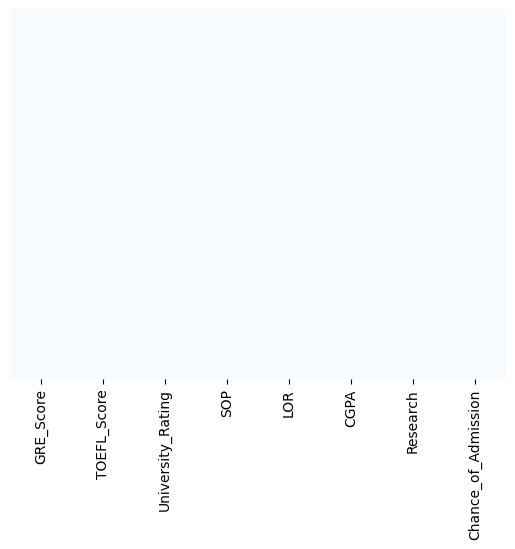

In [13]:
# Cek apa ada nilai kosong
sns.heatmap(university_df.isnull(), yticklabels = False, cbar = False, cmap = "Blues")
plt.show()

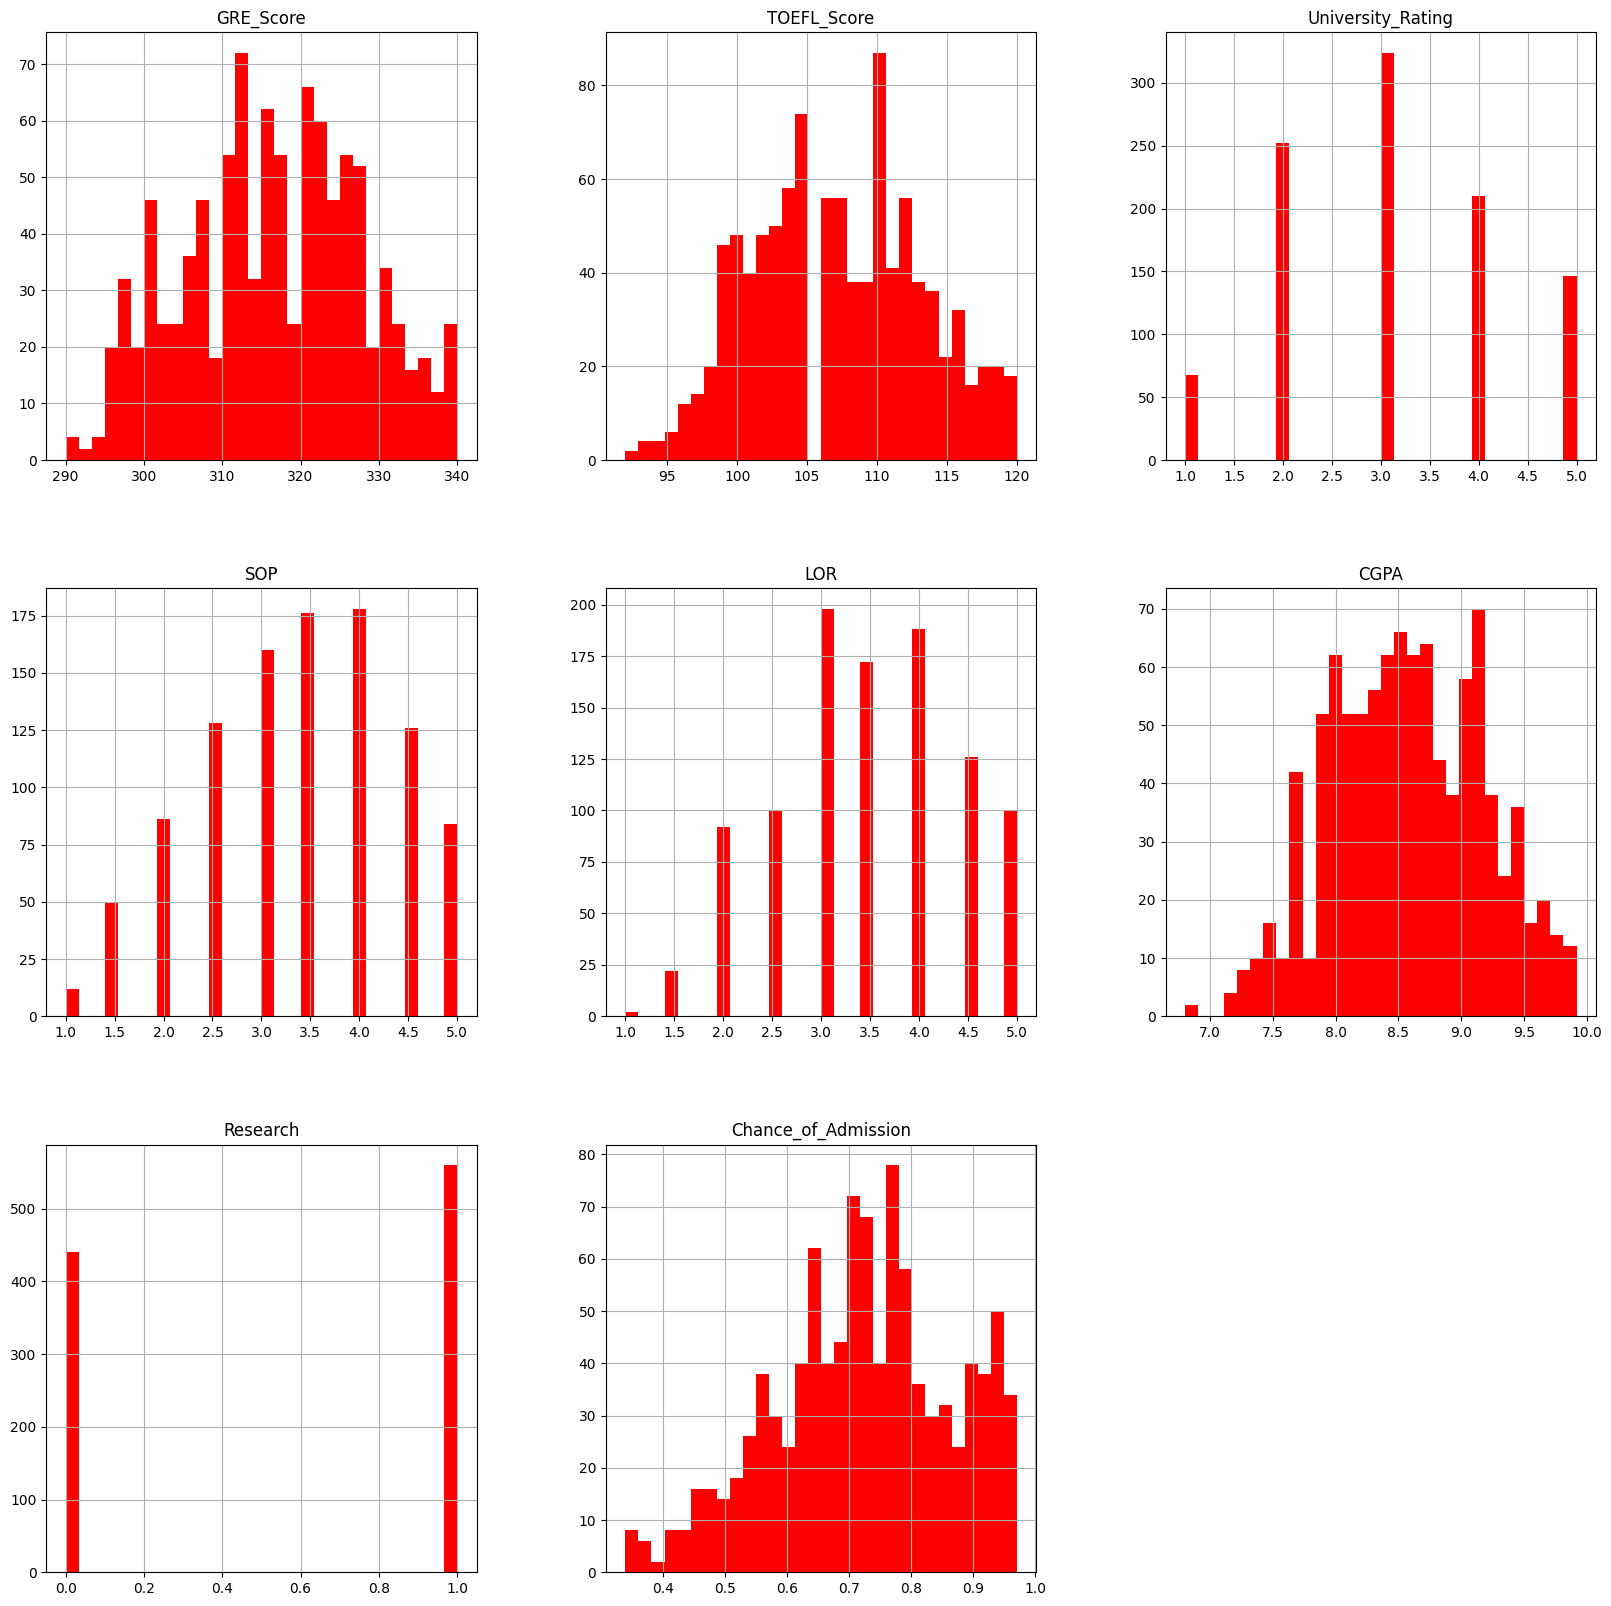

In [14]:
university_df.hist(bins = 30, figsize = (20,20), color = "r")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

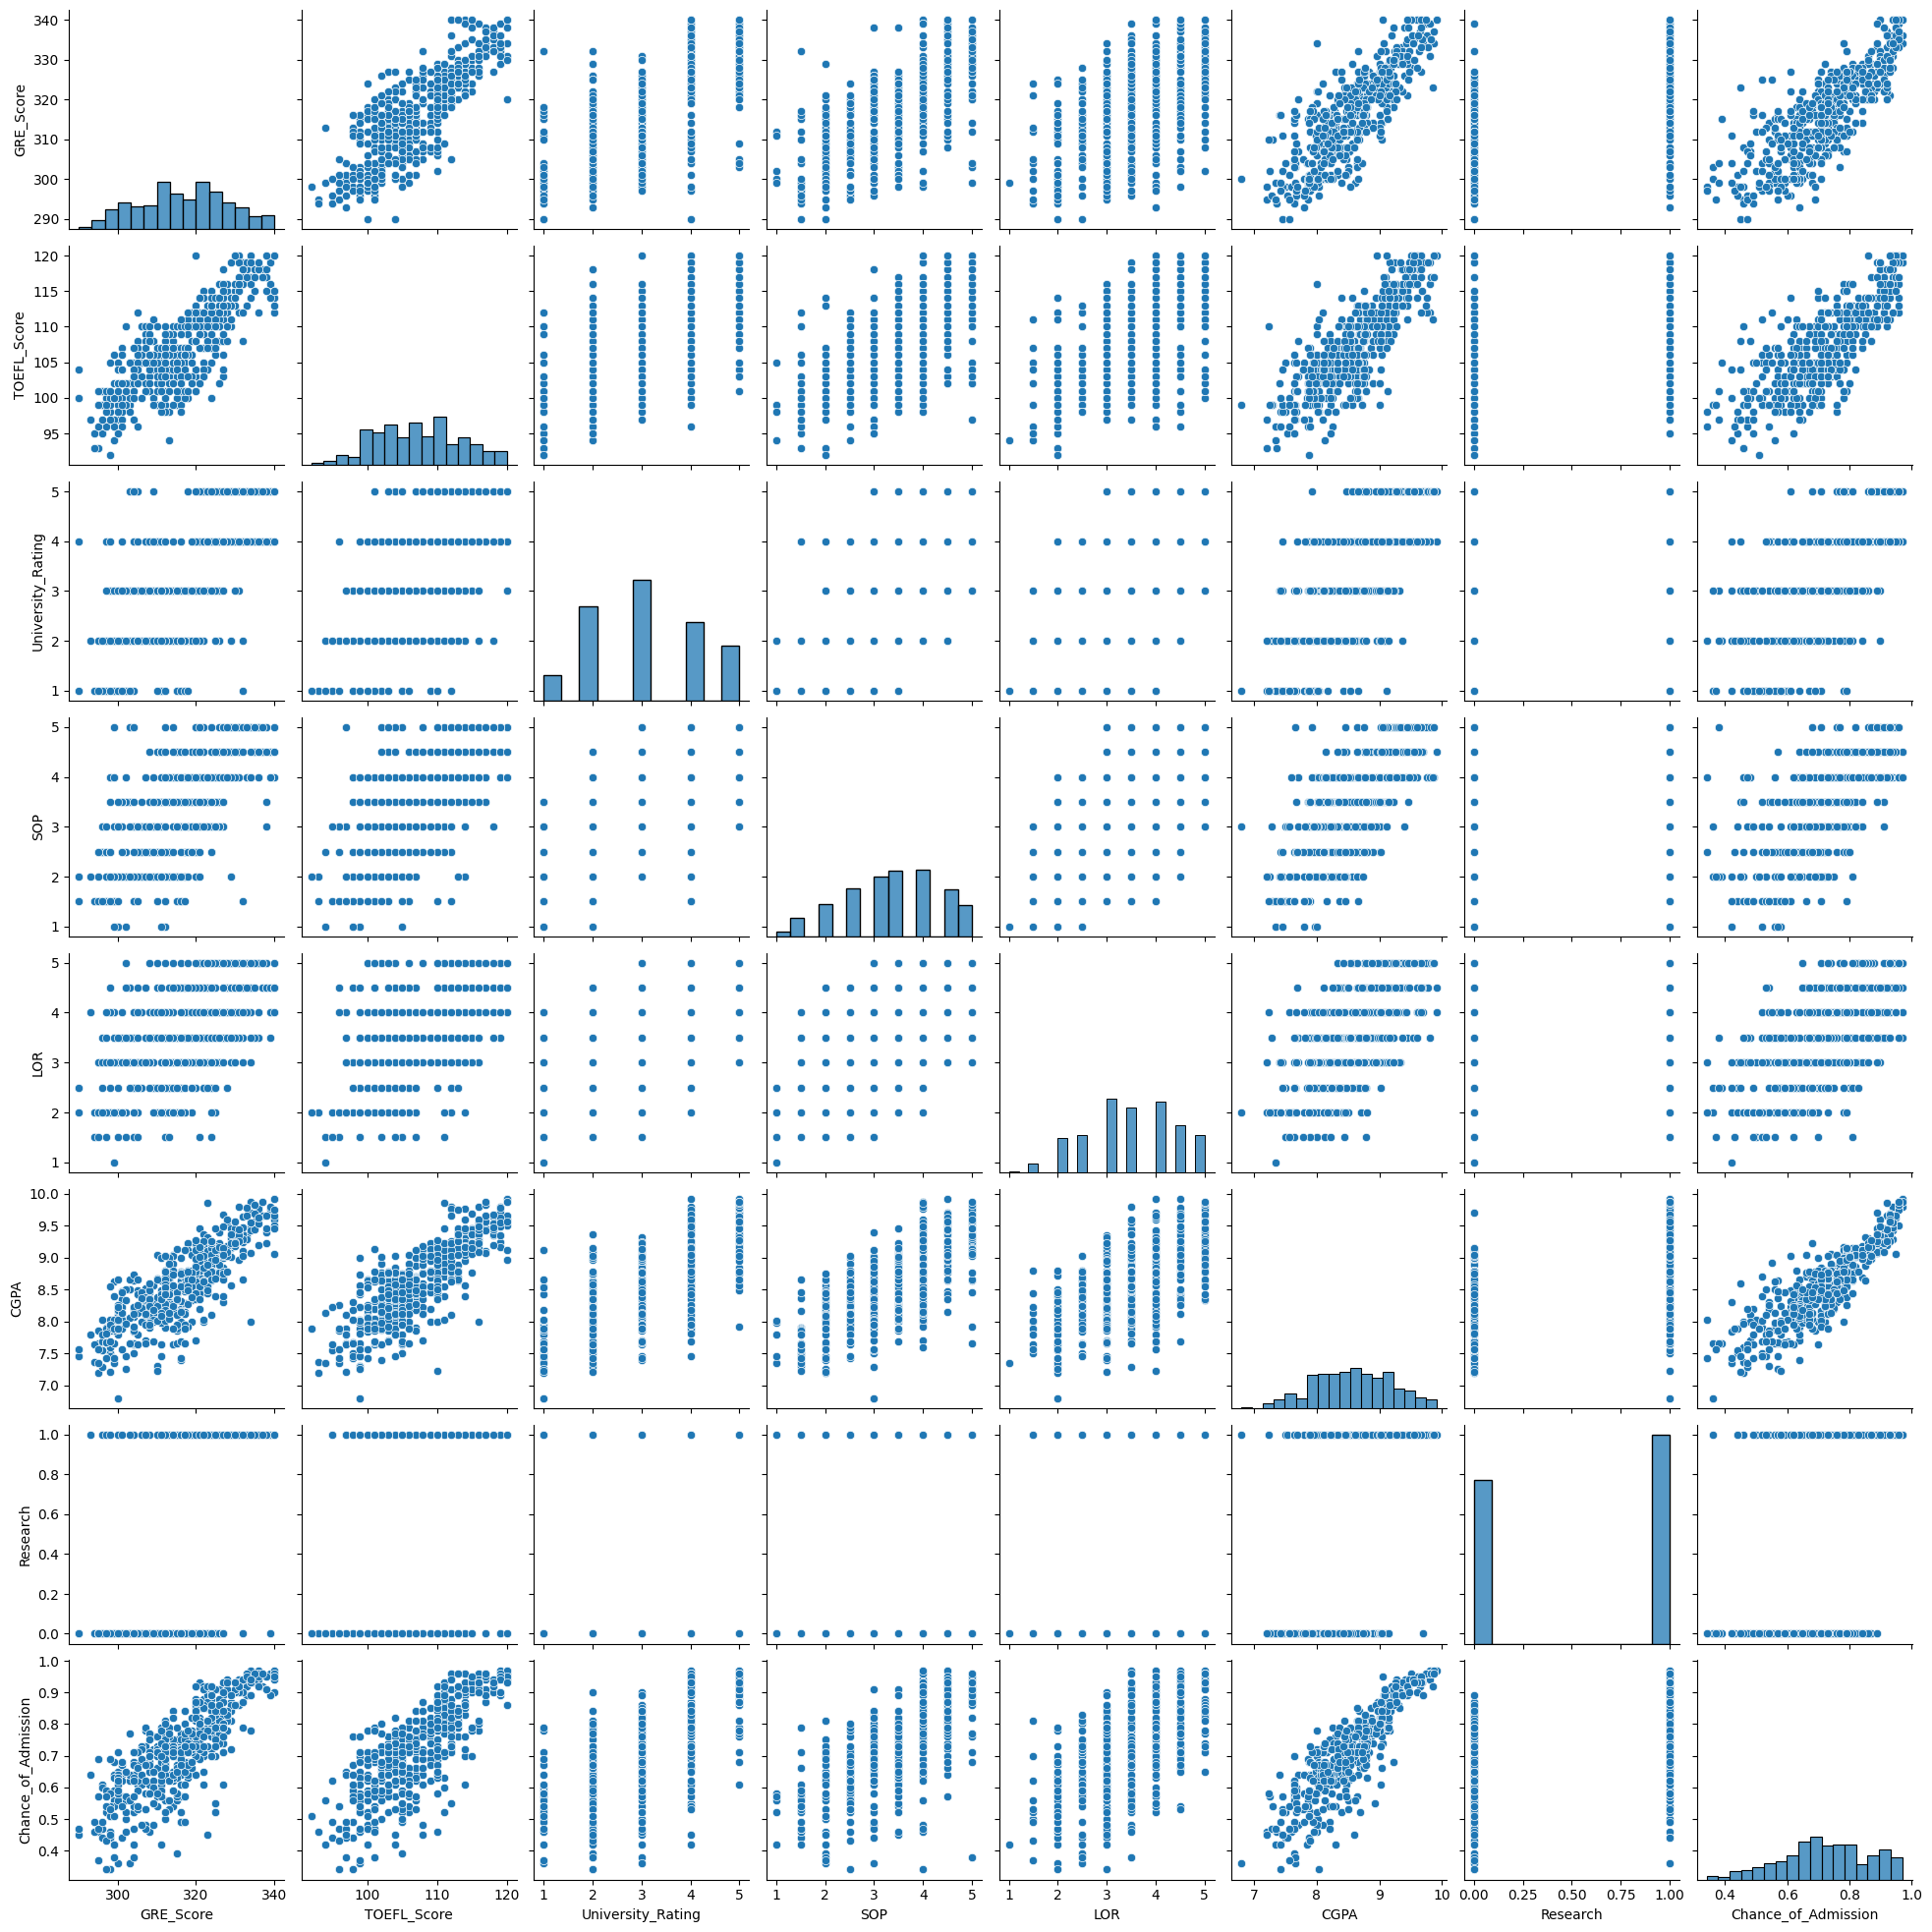

In [15]:
sns.pairplot(university_df)
plt.show

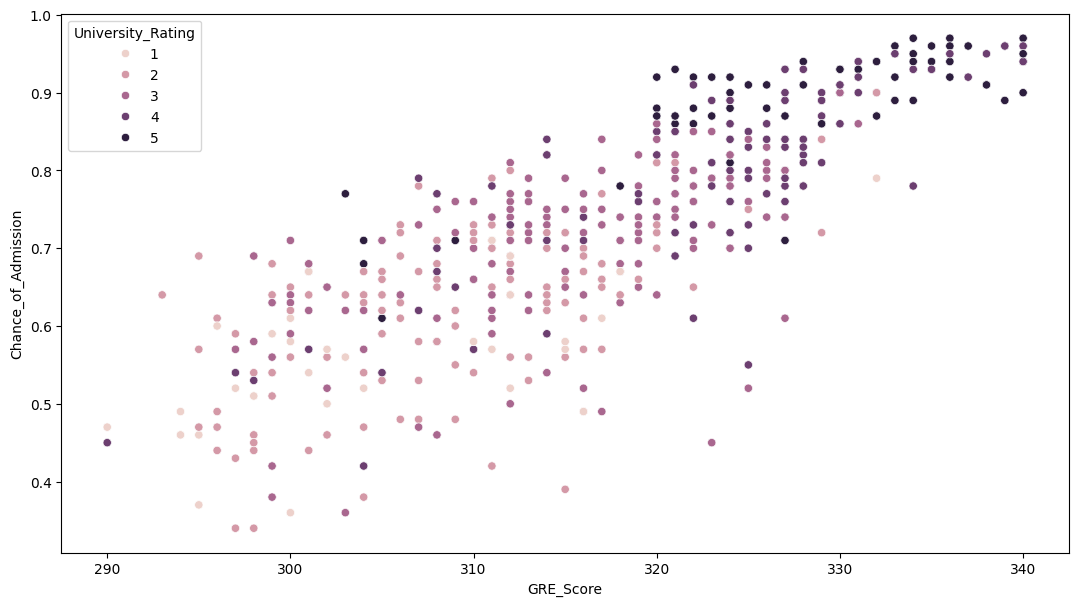

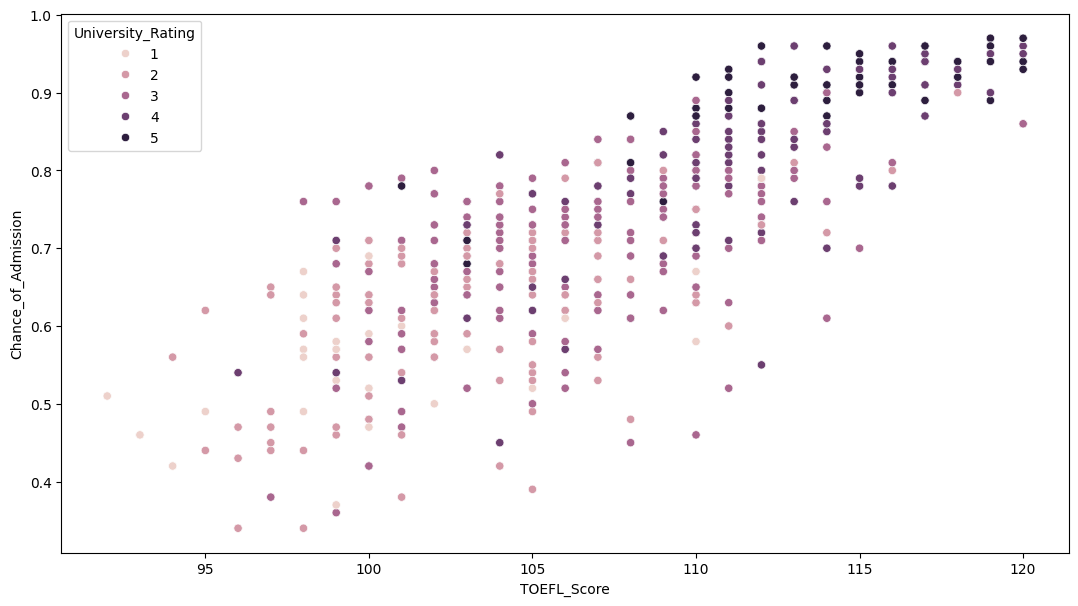

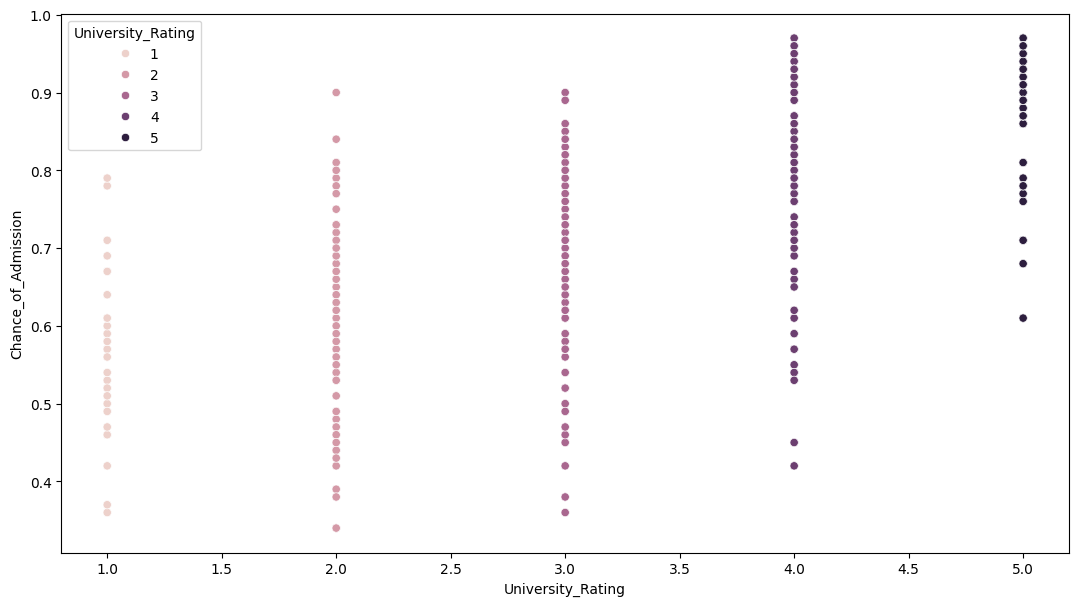

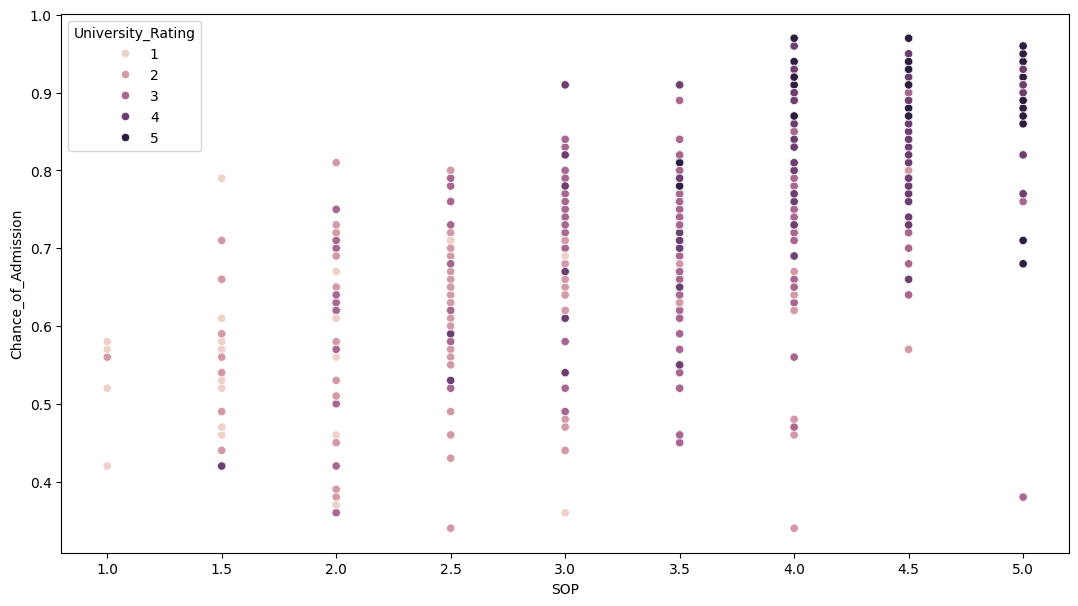

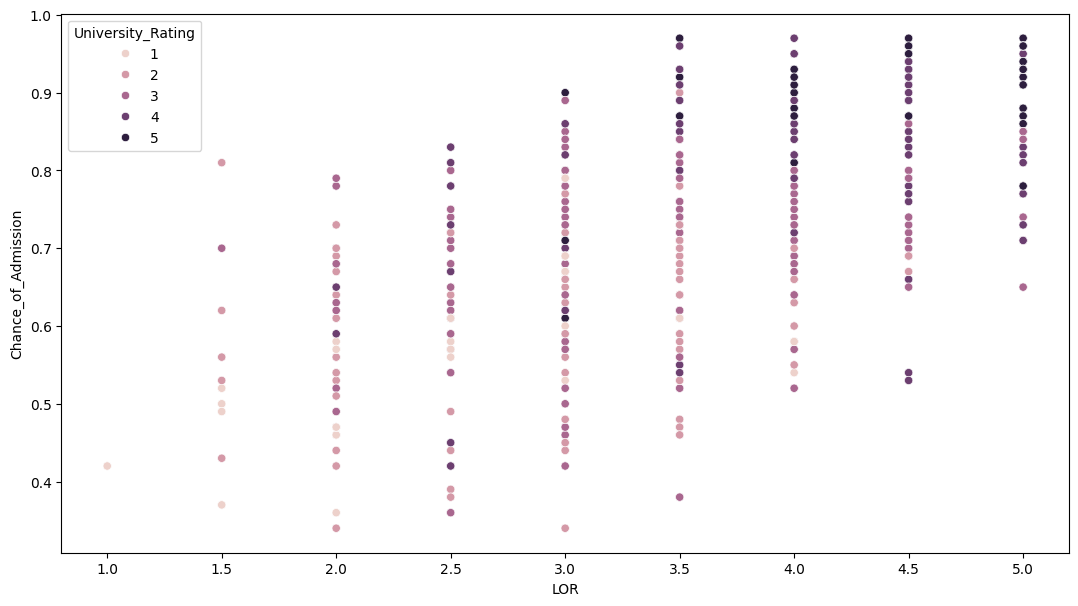

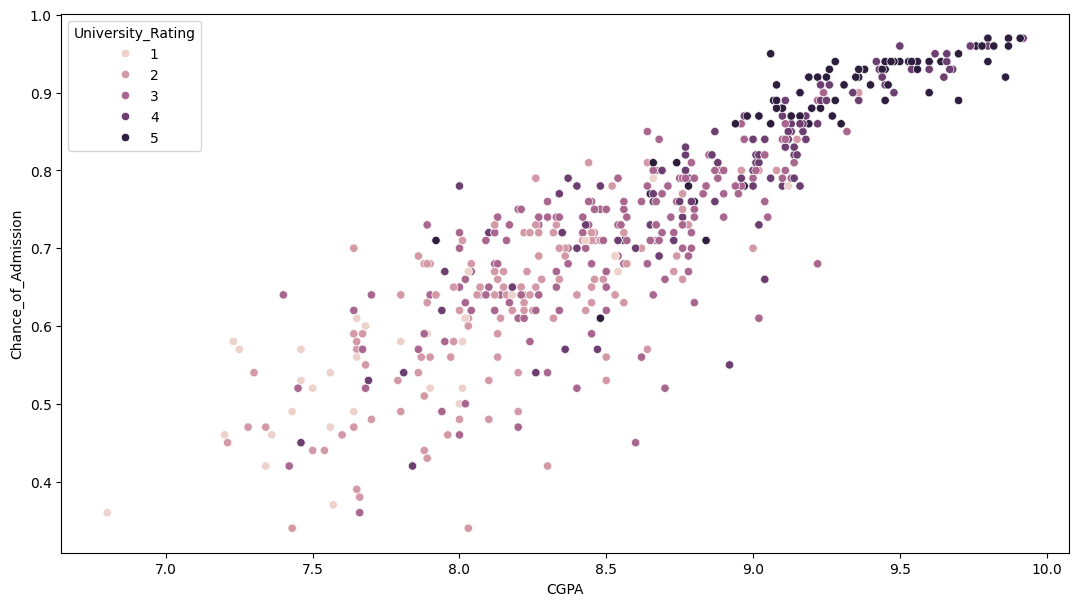

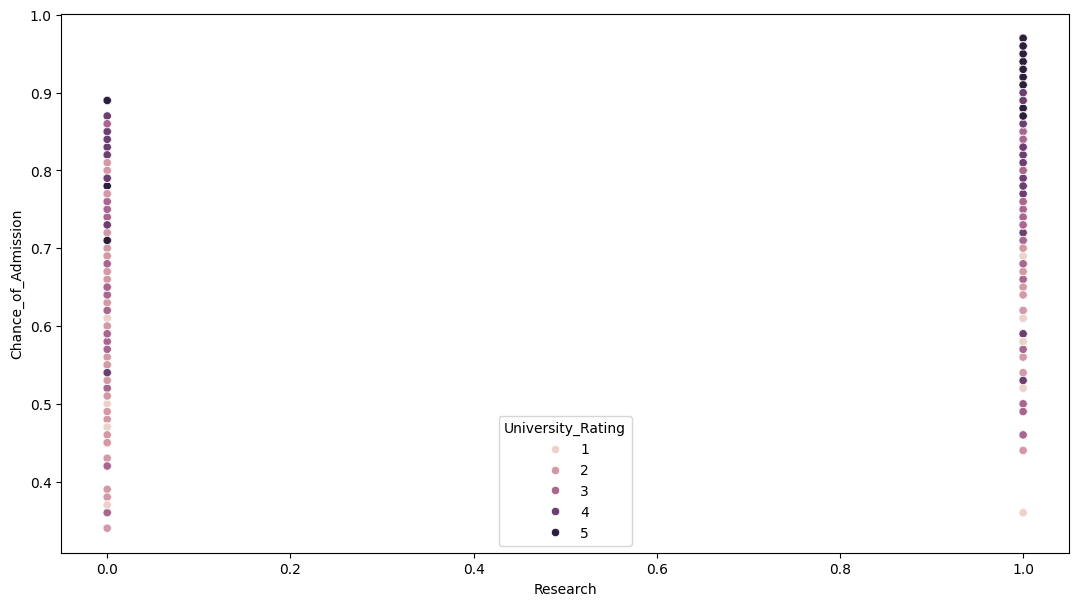

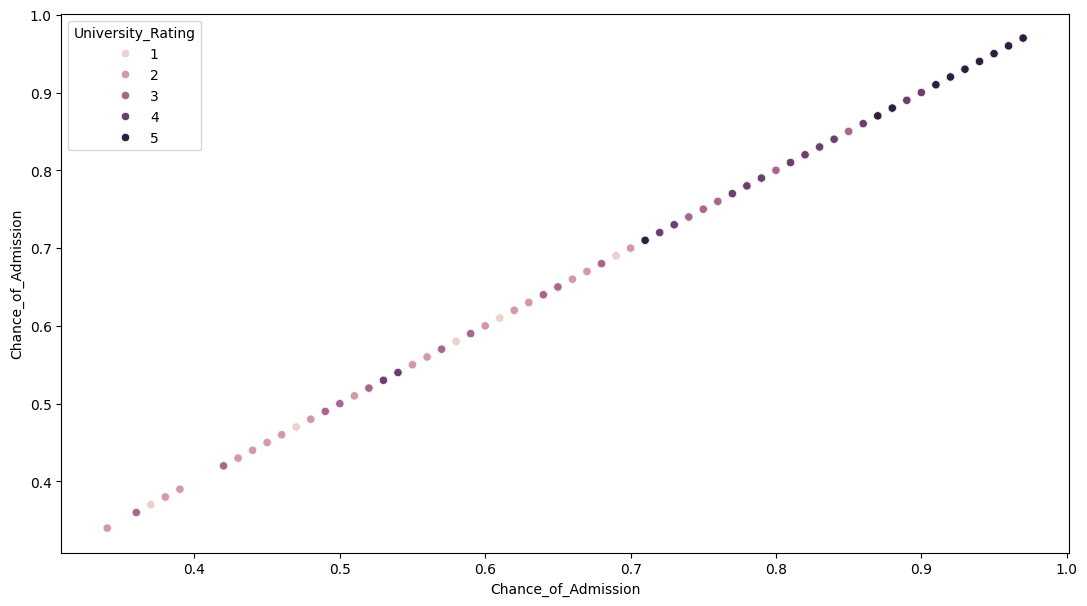

In [16]:
# Scatterplot
for i in university_df.columns:
  plt.figure(figsize = (13,7))
  sns.scatterplot(x = i, y ='Chance_of_Admission', hue = "University_Rating", hue_norm = (1, 5), data = university_df)
  plt.show()

## Latihan

In [17]:
# Plot Matriks korelasi
# Berikan komentar pada matriks korelasi

In [18]:
university_df.corr()

,GRE_Score,TOEFL_Score,University_Rating,SOP,LOR,CGPA,Research,Chance_of_Admission
GRE_Score,1.000000,0.827076,0.635376,0.613498,0.524679,0.825878,0.563398,0.810351
TOEFL_Score,0.827076,1.000000,0.649725,0.644374,0.541340,0.810644,0.466453,0.791921
University_Rating,0.635376,0.649725,1.000000,0.728024,0.608651,0.705254,0.427047,0.690132
SOP,0.613498,0.644374,0.728024,1.000000,0.663707,0.712154,0.408116,0.684137
LOR,0.524679,0.541340,0.608651,0.663707,1.000000,0.637469,0.372526,0.645365
CGPA,0.825878,0.810644,0.705254,0.712154,0.637469,1.000000,0.501311,0.882413
Research,0.563398,0.466453,0.427047,0.408116,0.372526,0.501311,1.000000,0.545871
Chance_of_Admission,0.810351,0.791921,0.690132,0.684137,0.645365,0.882413,0.545871,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

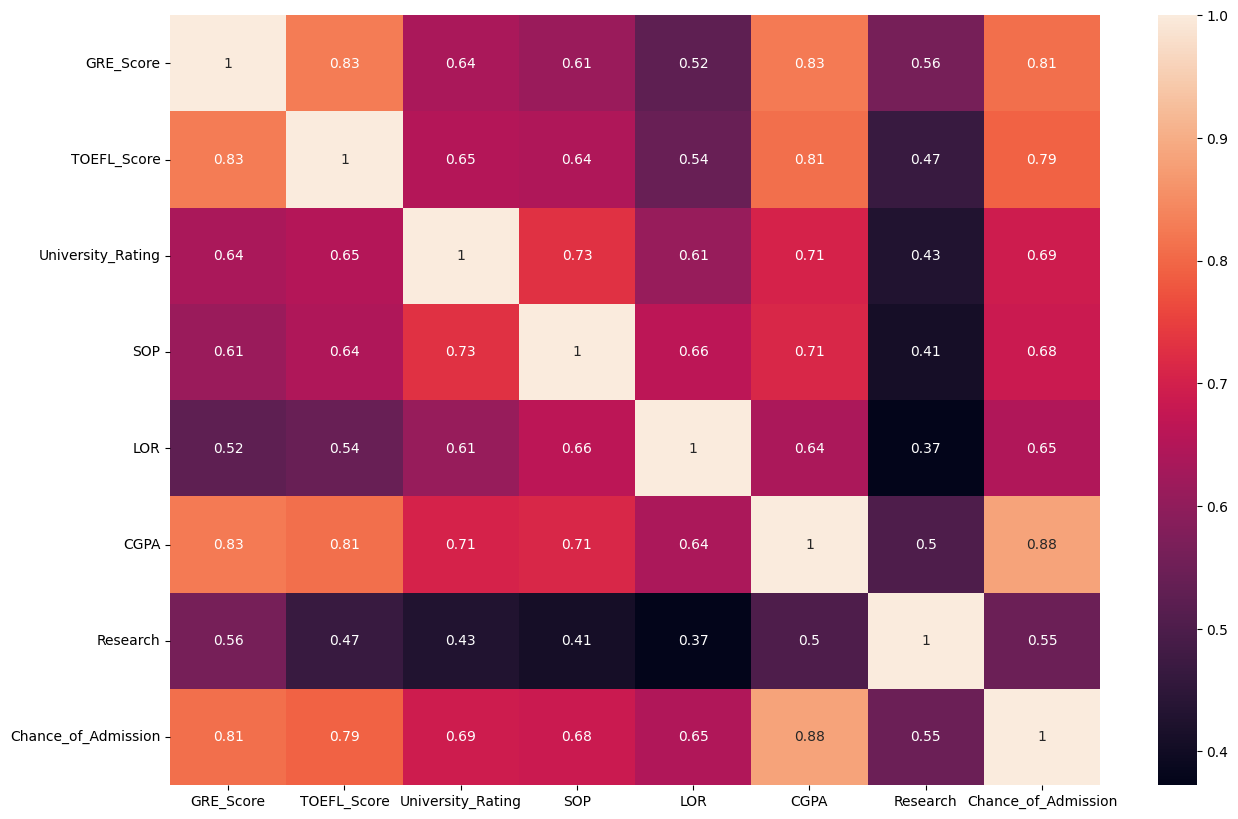

In [19]:
plt.figure(figsize = (15,10))
sns.heatmap(university_df.corr(), annot = True)
plt.show

# 3. Data Preprocessing

In [20]:
# cek isi terlebih dahulu
university_df.columns

Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admission'],
      dtype='object')

In [21]:
# Ambil semua data kecuali 'Chance of admission'
X = university_df.drop(columns = ['Chance_of_Admission'])

In [22]:
y = university_df['Chance_of_Admission']

In [23]:
X.shape

(1000, 7)

In [24]:
y.shape

(1000,)

In [25]:
X = np.array(X)
y = np.array(y)

In [26]:
# Ubah ukuran array dari (1000,) ke (1000,1)
y = y.reshape(1000,1)
y.shape

(1000, 1)

## Data Splitting



In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

In [28]:
X_train.shape


(750, 7)

In [29]:
y_train.shape

(750, 1)

In [30]:
X_test.shape

(250, 7)

In [31]:
y_test.shape

(250, 1)

# 4. Modelling

In [32]:
# Latih model regresi XGBoost


model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 2, n_estimators = 100)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

# 5. Evaluation

In [33]:
# Memprediksi skor model yang dilatih menggunakan dataset pengujian

result = model.score(X_test, y_test)
print("R2 Score : {}".format(result))

R2 Score : 0.8559296501423784


In [34]:
# Membuat prediksi pada data uji
y_predict = model.predict(X_test)

In [35]:
y_predict

array([0.6027684 , 0.6694319 , 0.7558621 , 0.7778245 , 0.52087957,
       0.5719408 , 0.8186543 , 0.7784994 , 0.68806326, 0.80646354,
       0.548462  , 0.78705186, 0.6546764 , 0.7365487 , 0.73127794,
       0.66077363, 0.5812458 , 0.6201292 , 0.71692806, 0.54422075,
       0.68697834, 0.9365517 , 0.62589437, 0.8511856 , 0.46831453,
       0.9008402 , 0.6209497 , 0.78705186, 0.59971106, 0.6893504 ,
       0.7790473 , 0.78385967, 0.9380806 , 0.7964303 , 0.7176204 ,
       0.7483544 , 0.8214738 , 0.545743  , 0.6745033 , 0.8691104 ,
       0.69358546, 0.6258652 , 0.7919534 , 0.6414434 , 0.7570545 ,
       0.59947056, 0.8050635 , 0.94229615, 0.7058267 , 0.71960497,
       0.7326454 , 0.7342186 , 0.7761864 , 0.6207355 , 0.7176204 ,
       0.8164082 , 0.47266948, 0.6820917 , 0.6652965 , 0.6881693 ,
       0.91488117, 0.66439956, 0.9365517 , 0.70782936, 0.45796797,
       0.8029684 , 0.8610385 , 0.65585464, 0.79514927, 0.6453582 ,
       0.66439956, 0.6759803 , 0.7337075 , 0.9143762 , 0.74366

In [36]:
RMSE = float(format(np.sqrt(mean_squared_error(y_test, y_predict)),'.3f'))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)

print('RMSE =',RMSE, '\nMSE =',MSE, '\nMAE =',MAE, '\nR2 =', r2)

RMSE = 0.052 
MSE = 0.0026649347268834023 
MAE = 0.037184640946388244 
R2 = 0.8559296501423784


## 6. Hyperparameter Tuning

In [37]:
# Definisikan parameter yang ingin di-tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9]
}

# Inisialisasi model XGBoost
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', random_state=42)

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='r2', cv=5, verbose=1, n_jobs=-1)

In [38]:
# Latih GridSearchCV
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='r2', verbose=1)

In [39]:
# Cetak parameter terbaik dan skor terbaik
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best R2 score from GridSearchCV: {grid_search.best_score_}")

Best parameters found: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.7}
Best R2 score from GridSearchCV: 0.8886574528052483


In [40]:
# Gunakan model terbaik untuk prediksi dan evaluasi
best_model = grid_search.best_estimator_
y_predict_tuned = best_model.predict(X_test)

RMSE_tuned = float(format(np.sqrt(mean_squared_error(y_test, y_predict_tuned)),'.3f'))
MSE_tuned = mean_squared_error(y_test, y_predict_tuned)
MAE_tuned = mean_absolute_error(y_test, y_predict_tuned)
r2_tuned = r2_score(y_test, y_predict_tuned)

print('\nEvaluation with Tuned Model:')
print(f'RMSE = {RMSE_tuned}')
print(f'MSE = {MSE_tuned}')
print(f'MAE = {MAE_tuned}')
print(f'R2 = {r2_tuned}')


Evaluation with Tuned Model:
RMSE = 0.033
MSE = 0.0010934539932305665
MAE = 0.021150650062561033
R2 = 0.9408862446915632


In [41]:
import joblib

# Simpan model terbaik
joblib.dump(best_model, 'best_xgboost_model.pkl')
print("Best mMdel Saved")

Best mMdel Saved
